In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from PyLTSpice import RawRead

%config InlineBackend.figure_format = 'svg'

In [ ]:
"""
AFE Bandwidth and Frequency Response Analysis

This module analyzes the frequency domain characteristics of the analog front-end
including bandwidth, gain peaking, and aliasing performance.
"""

# ============================================
# Load Configuration
# ============================================
with open("config.yaml", "r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

# ============================================
# Output Directory Setup
# ============================================

REPORT_DIR = Path(config["paths"]["report_directory"])
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/05_Verification/ElectronicHardware/Simulation/Analog/ANA-004_bandwith_freq/04_Report


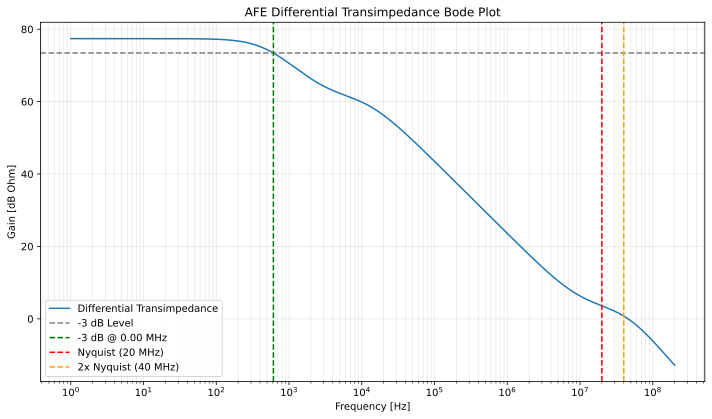

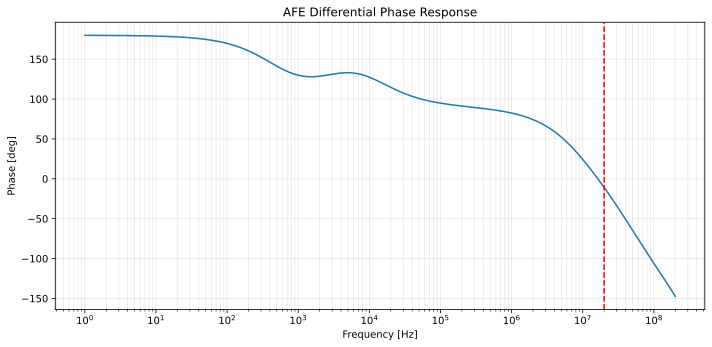

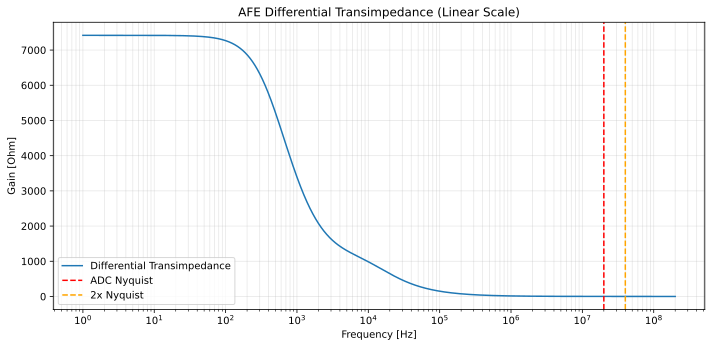


========== BANDWIDTH REPORT ==========
ADC Sampling Rate:       40.0 MSPS
ADC Nyquist Frequency:   20.0 MHz
--------------------------------------
Midband Gain:            6638.71 Ohm
Midband Gain (dB):       76.44 dB
-3 dB Bandwidth:         0.001 MHz
Effective Noise BW:      0.002 MHz
Gain Peaking:            0.96 dB
--------------------------------------
Gain @ Nyquist:          3.60 dB
Atten @ Nyquist:         -72.84 dB
Gain @ 2x Nyquist:       0.78 dB
Atten @ 2x Nyquist:      -75.67 dB
Roll-off slope:          -12.43 dB/dec



In [9]:
# ============================================================
# Configuration
# ============================================================
ADC_FS = 40e6
NYQUIST = ADC_FS / 2
ALIAS_FREQ = 2 * NYQUIST

RAW_PATH = "../02_SimulationModel/TbACGain.raw"
REPORT_ROOT = "./reports"
os.makedirs(REPORT_ROOT, exist_ok=True)

# ============================================================
# Load RAW File
# ============================================================
raw = RawRead(RAW_PATH)

freq = np.real(raw.get_trace("frequency").get_wave(0))
vout_p = raw.get_trace("V(out_p)").get_wave(0)
vout_n = raw.get_trace("V(out_n)").get_wave(0)

# Differential output
vout = vout_p - vout_n

v_real = np.real(vout)
v_imag = np.imag(vout)

mag = np.sqrt(v_real**2 + v_imag**2)
mag_db = 20 * np.log10(mag)
phase = np.degrees(np.arctan2(v_imag, v_real))

# ============================================================
# Midband Gain Calculation
# Use lowest decade above DC
# ============================================================
midband_region = (freq > 10) & (freq < 1000)
midband_gain = np.mean(mag[midband_region])
midband_gain_db = 20 * np.log10(midband_gain)

# ============================================================
# -3 dB Bandwidth
# ============================================================
target_db = midband_gain_db - 3
idx_3db = np.where(mag_db <= target_db)[0]
f_3db = freq[idx_3db[0]] if len(idx_3db) > 0 else None

# ============================================================
# Gain Peaking
# ============================================================
peak_gain_db = np.max(mag_db)
peaking_db = peak_gain_db - midband_gain_db

# ============================================================
# Effective Noise Bandwidth (ENBW)
# ============================================================
enbw = np.trapezoid(mag**2, freq) / (midband_gain**2)

# ============================================================
# Gain at Nyquist and 2x Nyquist
# ============================================================
idx_nyq = np.argmin(np.abs(freq - NYQUIST))
gain_nyq_db = mag_db[idx_nyq]
atten_nyq_db = gain_nyq_db - midband_gain_db

idx_alias = np.argmin(np.abs(freq - ALIAS_FREQ))
gain_alias_db = mag_db[idx_alias]
atten_alias_db = gain_alias_db - midband_gain_db

# ============================================================
# Roll-off slope estimation (dB/dec)
# between 0.5*NYQUIST and 5*NYQUIST if available
# ============================================================
freq_low = NYQUIST / 2
freq_high = min(freq[-1], 5 * NYQUIST)

idx1 = np.argmin(np.abs(freq - freq_low))
idx2 = np.argmin(np.abs(freq - freq_high))

slope_db_per_dec = (mag_db[idx2] - mag_db[idx1]) / (
    np.log10(freq[idx2]) - np.log10(freq[idx1])
)

# ============================================================
# Bode Magnitude Plot
# ============================================================
plt.figure(figsize=(10, 6))
plt.semilogx(freq, mag_db, label="Differential Transimpedance")

plt.axhline(target_db, color="gray", linestyle="--", label="-3 dB Level")

if f_3db:
    plt.axvline(
        f_3db, color="green", linestyle="--", label=f"-3 dB @ {f_3db / 1e6:.2f} MHz"
    )

plt.axvline(NYQUIST, color="red", linestyle="--", label="Nyquist (20 MHz)")

plt.axvline(ALIAS_FREQ, color="orange", linestyle="--", label="2x Nyquist (40 MHz)")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [dB Ohm]")
plt.title("AFE Differential Transimpedance Bode Plot")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(REPORT_DIR / "AFEBodeMagnitude.svg", format="svg")

plt.show()

# ============================================================
# Phase Plot
# ============================================================
plt.figure(figsize=(10, 5))
plt.semilogx(freq, phase)
plt.axvline(NYQUIST, color="red", linestyle="--")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.title("AFE Differential Phase Response")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.savefig(REPORT_DIR / "AFEPhaseResponse.svg", format="svg")

plt.show()

# ============================================================
# Linear Magnitude Plot (Peaking Visibility)
# ============================================================
plt.figure(figsize=(10, 5))
plt.semilogx(freq, mag, label="Differential Transimpedance")
plt.axvline(NYQUIST, color="red", linestyle="--", label="ADC Nyquist")
plt.axvline(ALIAS_FREQ, color="orange", linestyle="--", label="2x Nyquist")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [Ohm]")
plt.title("AFE Differential Transimpedance (Linear Scale)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(REPORT_DIR / "AFELinearGain.svg", format="svg")

plt.show()

# ============================================================
# Summary Table
# ============================================================
print("\n========== BANDWIDTH REPORT ==========")
print(f"ADC Sampling Rate:       {ADC_FS / 1e6:.1f} MSPS")
print(f"ADC Nyquist Frequency:   {NYQUIST / 1e6:.1f} MHz")
print("--------------------------------------")
print(f"Midband Gain:            {midband_gain:.2f} Ohm")
print(f"Midband Gain (dB):       {midband_gain_db:.2f} dB")

if f_3db:
    print(f"-3 dB Bandwidth:         {f_3db / 1e6:.3f} MHz")
else:
    print("-3 dB Bandwidth:         Not found")

print(f"Effective Noise BW:      {enbw / 1e6:.3f} MHz")
print(f"Gain Peaking:            {peaking_db:.2f} dB")
print("--------------------------------------")
print(f"Gain @ Nyquist:          {gain_nyq_db:.2f} dB")
print(f"Atten @ Nyquist:         {atten_nyq_db:.2f} dB")
print(f"Gain @ 2x Nyquist:       {gain_alias_db:.2f} dB")
print(f"Atten @ 2x Nyquist:      {atten_alias_db:.2f} dB")
print(f"Roll-off slope:          {slope_db_per_dec:.2f} dB/dec")
print("======================================\n")

# ============================================================
# Simple Risk Flags
# ============================================================
if atten_nyq_db > -3:
    print("WARNING: Little attenuation at Nyquist. Aliasing risk possible.")

if atten_alias_db > -10:
    print("WARNING: Insufficient attenuation at 2x Nyquist.")

if peaking_db > 2:
    print("WARNING: Excessive gain peaking detected.")